In [1]:
import pandas, numpy

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(1/3), 9*(4/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
enrichments_file = '/Users/adrian/research/bmcbf/073_bologna/results/enrichment/clusterProfiler_enrichments.firstVenn.tsv'

In [4]:
df = pandas.read_csv(enrichments_file, sep='\t')
df

,Cluster,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
1,leftList,R-HSA-1474244,Extracellular matrix organization,73/833,321/11214,0.227414,3.061494,10.615113,1.436461e-18,1.867399e-15,1.732825e-15,1634/960/3381/1298/3918/1301/2192/9509/22795/3...,73
2,leftList,R-HSA-1474290,Collagen formation,25/833,90/11214,0.277778,3.739496,7.391375,4.590572e-09,2.387273e-06,2.215235e-06,1298/3918/1301/9509/55214/4318/1303/4015/1294/...,25
3,leftList,R-HSA-1566948,Elastic fibre formation,17/833,44/11214,0.386364,5.201299,7.909465,5.509092e-09,2.387273e-06,2.215235e-06,2192/7042/7040/3696/4015/2202/7043/650/8200/40...,17
4,leftList,R-HSA-1442490,Collagen degradation,18/833,64/11214,0.281250,3.786239,6.331911,5.436671e-07,1.766918e-04,1.639585e-04,1298/1301/4320/4318/1303/1294/1514/4316/4322/5...,18
5,leftList,R-HSA-1474228,Degradation of the extracellular matrix,28/833,140/11214,0.200000,2.692437,5.708054,1.125456e-06,2.399435e-04,2.226521e-04,1634/960/1298/3918/1301/4320/4318/1303/1294/48...,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,middleList,R-HSA-6788467,IL-6-type cytokine receptor ligand interactions,3/155,17/11214,0.176471,12.767362,5.748064,1.527554e-03,4.383417e-02,3.894040e-02,9244/3976/1489,3
70,middleList,R-HSA-381426,Regulation of Insulin-like Growth Factor (IGF)...,7/155,125/11214,0.056000,4.051510,4.061556,1.720123e-03,4.730339e-02,4.202231e-02,91851/7076/60676/6696/4148/3489/255738,7
71,rightList,R-HSA-69273,Cyclin A/B1/B2 associated events during G2/M t...,7/373,32/11214,0.218750,6.576575,5.859539,6.978116e-05,4.457676e-02,4.279584e-02,55355/9088/8900/891/993/5347/983,7
72,rightList,R-HSA-6809371,Formation of the cornified envelope,14/373,129/11214,0.108527,3.262797,4.794610,9.627173e-05,4.457676e-02,4.279584e-02,5318/5317/3875/5493/5266/1825/3855/2125/3856/3...,14


In [5]:
contrasts = []
for element in df['Cluster']:
    if element not in contrasts:
        contrasts.append(element)

print(contrasts)

['leftList', 'middleList', 'rightList']


In [6]:
terms_to_use = []
top_ten_categories = []
for contrast in contrasts:
    
    print(contrast)
    sub = df[df['Cluster'] == contrast]
    all_observed_gene_lists = []
    contrast_terms = []
    top_ten = []
    
    for index, row in sub.iterrows():
        
        
        genes = row['geneID'].split('/')
        print('\t', row['ID'], row['Description'], len(genes))
        
        # checking the overlap
        overlap = False
        max_overlap = 0
        for element in all_observed_gene_lists:
            intersect = list(set(element) & set(genes))
            relative_intersect = len(intersect)/len(genes)
            #print('\t\t\t intersect is', len(intersect), relative_intersect)
            if max_overlap < relative_intersect:
                max_overlap = relative_intersect
            if relative_intersect > 0.9:
                overlap=True
            
        all_observed_gene_lists.append(genes)

        #print('\t', overlap)
        #print()
        if overlap == False:
            print('\t accepting', row['ID'], row['Description'], 'because overlap is', max_overlap)
            contrast_terms.append(row['ID'])
            if len(contrast_terms) <= 10:
                top_ten.append(row['ID'])
        else:
            print('\t rejecting', row['ID'], row['Description'], 'because overlap is', max_overlap)
        print()

    # end of contrast
    terms_to_use.append(contrast_terms)
    top_ten_categories.append(top_ten)
    print()
    #print(terms_to_use)

leftList
	 R-HSA-1474244 Extracellular matrix organization 73
	 accepting R-HSA-1474244 Extracellular matrix organization because overlap is 0

	 R-HSA-1474290 Collagen formation 25
	 rejecting R-HSA-1474290 Collagen formation because overlap is 1.0

	 R-HSA-1566948 Elastic fibre formation 17
	 rejecting R-HSA-1566948 Elastic fibre formation because overlap is 1.0

	 R-HSA-1442490 Collagen degradation 18
	 rejecting R-HSA-1442490 Collagen degradation because overlap is 1.0

	 R-HSA-1474228 Degradation of the extracellular matrix 28
	 rejecting R-HSA-1474228 Degradation of the extracellular matrix because overlap is 1.0

	 R-HSA-198725 Nuclear Events (kinase and transcription factor activation) 17
	 accepting R-HSA-198725 Nuclear Events (kinase and transcription factor activation) because overlap is 0

	 R-HSA-2022090 Assembly of collagen fibrils and other multimeric structures 17
	 rejecting R-HSA-2022090 Assembly of collagen fibrils and other multimeric structures because overlap is 1

In [7]:
for content in terms_to_use:
    print(len(content), content)

print()

for top_ten in top_ten_categories:
    print(len(top_ten), top_ten)

union_list = list(set(item for sublist in top_ten_categories for item in sublist))

print()

print(len(union_list), union_list)

19 ['R-HSA-1474244', 'R-HSA-198725', 'R-HSA-191273', 'R-HSA-114608', 'R-HSA-9694614', 'R-HSA-166520', 'R-HSA-76002', 'R-HSA-3560782', 'R-HSA-6785807', 'R-HSA-8957275', 'R-HSA-3781865', 'R-HSA-202733', 'R-HSA-416700', 'R-HSA-2022928', 'R-HSA-1630316', 'R-HSA-373755', 'R-HSA-5668914', 'R-HSA-1369062', 'R-HSA-5576891']
11 ['R-HSA-1474244', 'R-HSA-6806834', 'R-HSA-6785807', 'R-HSA-186797', 'R-HSA-2173782', 'R-HSA-419812', 'R-HSA-6783589', 'R-HSA-9925563', 'R-HSA-5578768', 'R-HSA-9734767', 'R-HSA-381426']
3 ['R-HSA-69273', 'R-HSA-6809371', 'R-HSA-156711']

10 ['R-HSA-1474244', 'R-HSA-198725', 'R-HSA-191273', 'R-HSA-114608', 'R-HSA-9694614', 'R-HSA-166520', 'R-HSA-76002', 'R-HSA-3560782', 'R-HSA-6785807', 'R-HSA-8957275']
10 ['R-HSA-1474244', 'R-HSA-6806834', 'R-HSA-6785807', 'R-HSA-186797', 'R-HSA-2173782', 'R-HSA-419812', 'R-HSA-6783589', 'R-HSA-9925563', 'R-HSA-5578768', 'R-HSA-9734767']
3 ['R-HSA-69273', 'R-HSA-6809371', 'R-HSA-156711']

21 ['R-HSA-9734767', 'R-HSA-69273', 'R-HSA-9925563

[['R-HSA-1474244', 'R-HSA-198725', 'R-HSA-191273', 'R-HSA-114608', 'R-HSA-9694614', 'R-HSA-166520', 'R-HSA-76002', 'R-HSA-3560782', 'R-HSA-6785807', 'R-HSA-8957275', 'R-HSA-3781865', 'R-HSA-202733', 'R-HSA-416700', 'R-HSA-2022928', 'R-HSA-1630316', 'R-HSA-373755', 'R-HSA-5668914', 'R-HSA-1369062', 'R-HSA-5576891'], ['R-HSA-1474244', 'R-HSA-6806834', 'R-HSA-6785807', 'R-HSA-186797', 'R-HSA-2173782', 'R-HSA-419812', 'R-HSA-6783589', 'R-HSA-9925563', 'R-HSA-5578768', 'R-HSA-9734767', 'R-HSA-381426'], ['R-HSA-69273', 'R-HSA-6809371', 'R-HSA-156711']]
-1 R-HSA-1474244
-2 R-HSA-198725
-3 R-HSA-191273
-4 R-HSA-114608
-5 R-HSA-9694614
-6 R-HSA-166520
-7 R-HSA-76002
-8 R-HSA-3560782
-9 R-HSA-6785807
-10 R-HSA-8957275
-1 R-HSA-1474244
-11 R-HSA-6806834
-9 R-HSA-6785807
-12 R-HSA-186797
-13 R-HSA-2173782
-14 R-HSA-419812
-15 R-HSA-6783589
-16 R-HSA-9925563
-17 R-HSA-5578768
-18 R-HSA-9734767
-19 R-HSA-69273
-20 R-HSA-6809371
-21 R-HSA-156711


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_2140/515711165.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  matplotlib.pyplot.tight_layout()


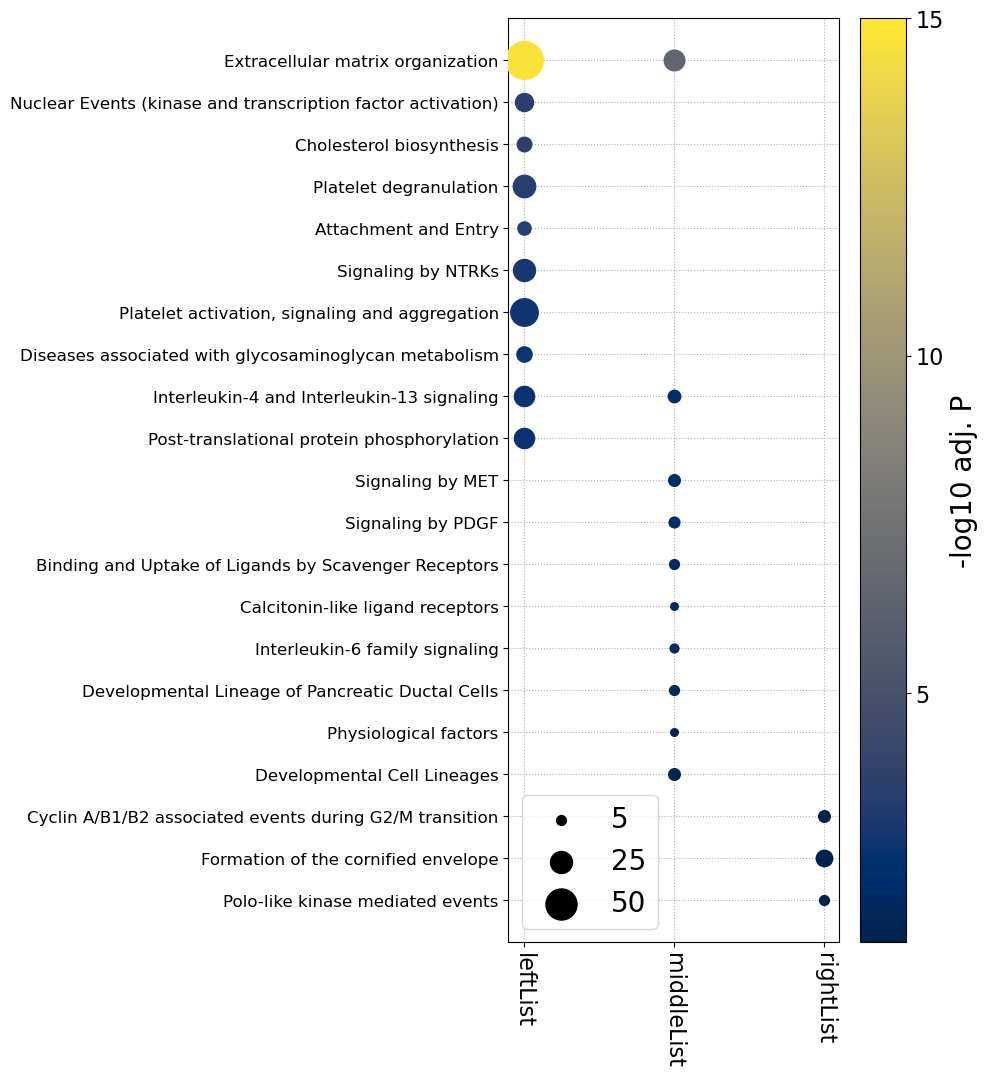

In [8]:
terms_used_so_far = {}
depth = 0
print(terms_to_use)
factor_size_circles = 10
for i in range(len(terms_to_use)):
    for j in range(len(terms_to_use[i])):
        element = terms_to_use[i][j]

        if element in union_list:
        
            if element in terms_used_so_far.keys():
                location = terms_used_so_far[element]
            else:
                depth = depth - 1
                location = depth
    
            # define color
            adjp = -numpy.log10(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['p.adjust'].values[0])
            #print(element, adjp)
    
            # define size
            thesize = int(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['GeneRatio'].values[0].split('/')[0])
            
            # make a point        
            matplotlib.pyplot.scatter(i, location, s=thesize*factor_size_circles, c=adjp, zorder=9999, cmap='cividis', vmin=-numpy.log10(0.05), vmax=15)
            terms_used_so_far[element] = location
            print(location, element)


matplotlib.pyplot.colorbar(label='-log10 adj. P', ticks=[5, 10, 15])

# close the figure
a = []; b = []
for element in terms_used_so_far.keys():
    description = list(df[df['ID'] == element]['Description'].values)[0]
    a.append(description)
    b.append(terms_used_so_far[element])

for area in factor_size_circles*numpy.array([5, 25, 50]):
    matplotlib.pyplot.scatter([], [], c='black', edgecolor=None, s=area, label=str(int(area/factor_size_circles)))
matplotlib.pyplot.legend(loc=3)

matplotlib.pyplot.yticks(b, a, fontsize=12)
matplotlib.pyplot.xticks(list(range(len(contrasts))), 
                         contrasts, 
                         rotation=-90)

#matplotlib.pyplot.ylim(-40.75, -0.25)
matplotlib.pyplot.grid(ls=':')
matplotlib.pyplot.tight_layout()

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('enrichment_firstvenn.svg')

In [9]:
list(range(len(contrasts)))

[0, 1, 2]

In [10]:
len(contrasts)

3